## Import

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

## `model.py`

In [17]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 4, 2, 1)   # 28 -> 14
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)  # 14 -> 7

        self.fc = nn.Linear(64 * 7 * 7, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc(x))

        return self.fc_mu(x), self.fc_logvar(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()

        self.fc1 = nn.Linear(latent_dim, 256)
        self.fc2 = nn.Linear(256, 64 * 7 * 7)

        self.deconv1 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, 4, 2, 1)

    def forward(self, z):
        x = F.relu(self.fc1(z))
        x = F.relu(self.fc2(x))

        x = x.view(-1, 64, 7, 7)
        x = F.relu(self.deconv1(x))
        return torch.sigmoid(self.deconv2(x))


class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()

        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

## `train.py`


In [18]:
def vae_loss(recon_x, x, mu, logvar):
    recon = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl, recon, kl

transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(latent_dim=20).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

train_total, train_recon, train_kl = [], [], []

for epoch in range(epochs):
    model.train()
    total_epoch_loss = 0

    for x, _ in loader:
        x = x.to(device)

        recon, mu, logvar = model(x)
        loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_total.append(loss.item() / x.size(0))
        train_recon.append(recon_l.item() / x.size(0))
        train_kl.append(kl_l.item() / x.size(0))

        total_epoch_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_epoch_loss / len(dataset):.4f}")

Epoch 1 | Loss: 183.5815
Epoch 2 | Loss: 123.7691
Epoch 3 | Loss: 112.1116
Epoch 4 | Loss: 108.3040
Epoch 5 | Loss: 106.3499
Epoch 6 | Loss: 104.8317
Epoch 7 | Loss: 103.7175
Epoch 8 | Loss: 102.9064
Epoch 9 | Loss: 102.2718
Epoch 10 | Loss: 101.7468


## Visualization

### Loss Curves

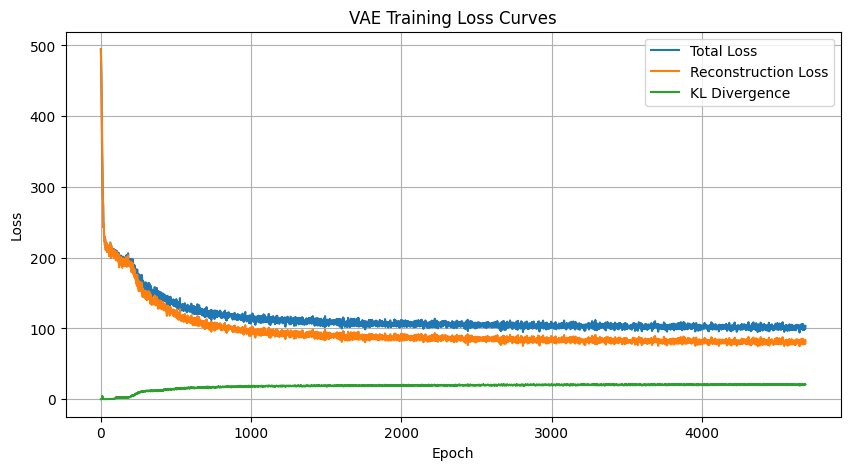

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(train_total, label="Total Loss")
plt.plot(train_recon, label="Reconstruction Loss")
plt.plot(train_kl, label="KL Divergence")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss Curves")
plt.legend()
plt.grid(True)

plt.show()

### Reconstruction Visualization

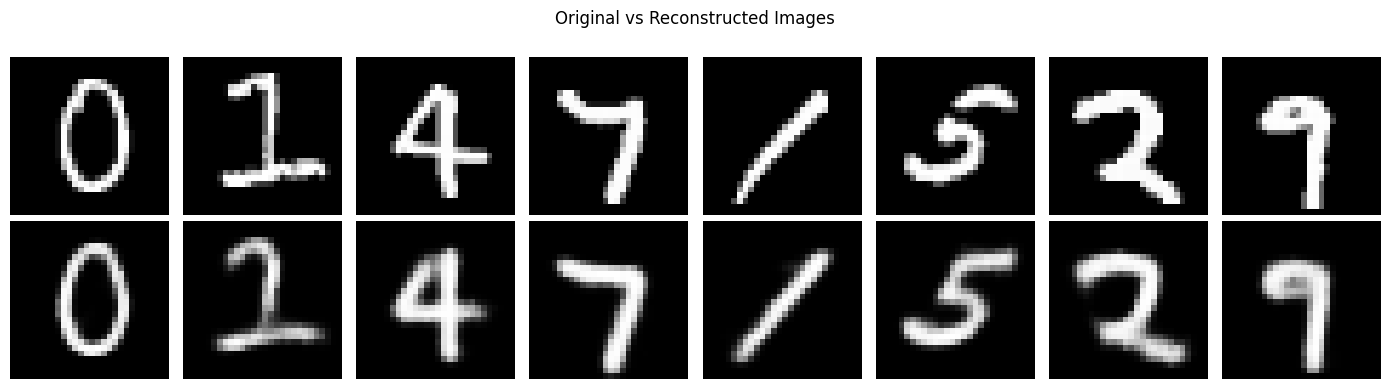

In [20]:
model.eval()

x, _ = next(iter(loader))
x = x.to(device)

with torch.no_grad():
    recon, _, _ = model(x)

x = x.cpu()
recon = recon.cpu()

n = 8

fig, axes = plt.subplots(2, n, figsize=(14, 4))

for i in range(n):

    # Original
    axes[0, i].imshow(x[i][0], cmap="gray")
    axes[0, i].axis("off")

    # Reconstruction
    axes[1, i].imshow(recon[i][0], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Recon", fontsize=12)

plt.suptitle("Original vs Reconstructed Images")
plt.tight_layout()

plt.show()

### Latent Space Visualization using PCA

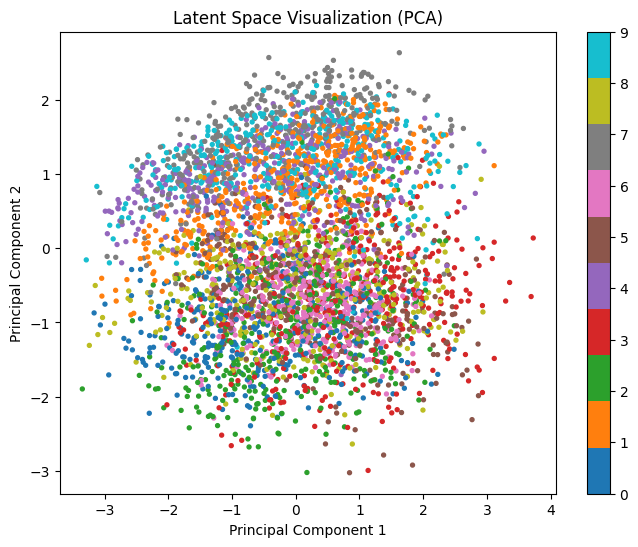

In [21]:
model.eval()

latents = []
labels = []

with torch.no_grad():

    for batch_idx, (x, y) in enumerate(loader):

        x = x.to(device)

        mu, _ = model.encoder(x)

        latents.append(mu.cpu().numpy())
        labels.append(y.numpy())

        # collect enough samples
        if batch_idx > 30:
            break

latents = np.concatenate(latents, axis=0)
labels = np.concatenate(labels, axis=0)

# PCA projection to 2D
z_2d = PCA(n_components=2).fit_transform(latents)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=8
)

plt.colorbar(scatter)
plt.title("Latent Space Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

### Latent Space Visualization using TSNE


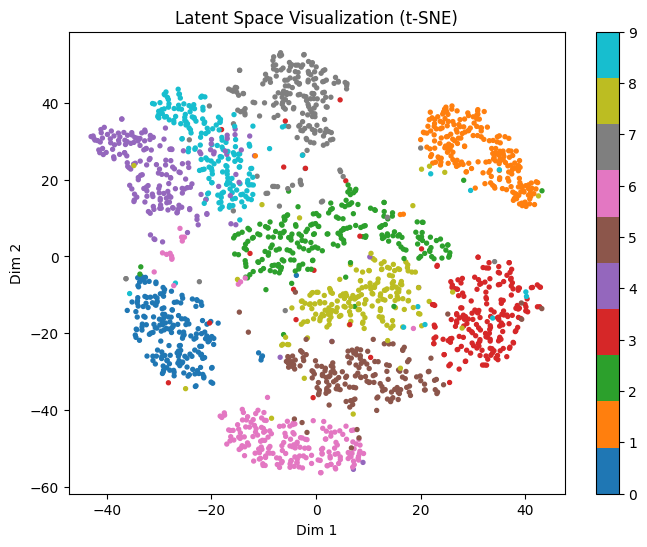

In [25]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import torch

model.eval()

latents = []
labels = []

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(loader):
        x = x.to(device)

        mu, _ = model.encoder(x)

        latents.append(mu.cpu().numpy())
        labels.append(y.numpy())

        if batch_idx > 30:
            break

latents = np.concatenate(latents, axis=0)
labels = np.concatenate(labels, axis=0)

max_samples = 2000
if latents.shape[0] > max_samples:
    idx = np.random.choice(latents.shape[0], max_samples, replace=False)
    latents = latents[idx]
    labels = labels[idx]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

z_2d = tsne.fit_transform(latents)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=8
)

plt.colorbar(scatter)
plt.title("Latent Space Visualization (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

### Latent Space Interpolation

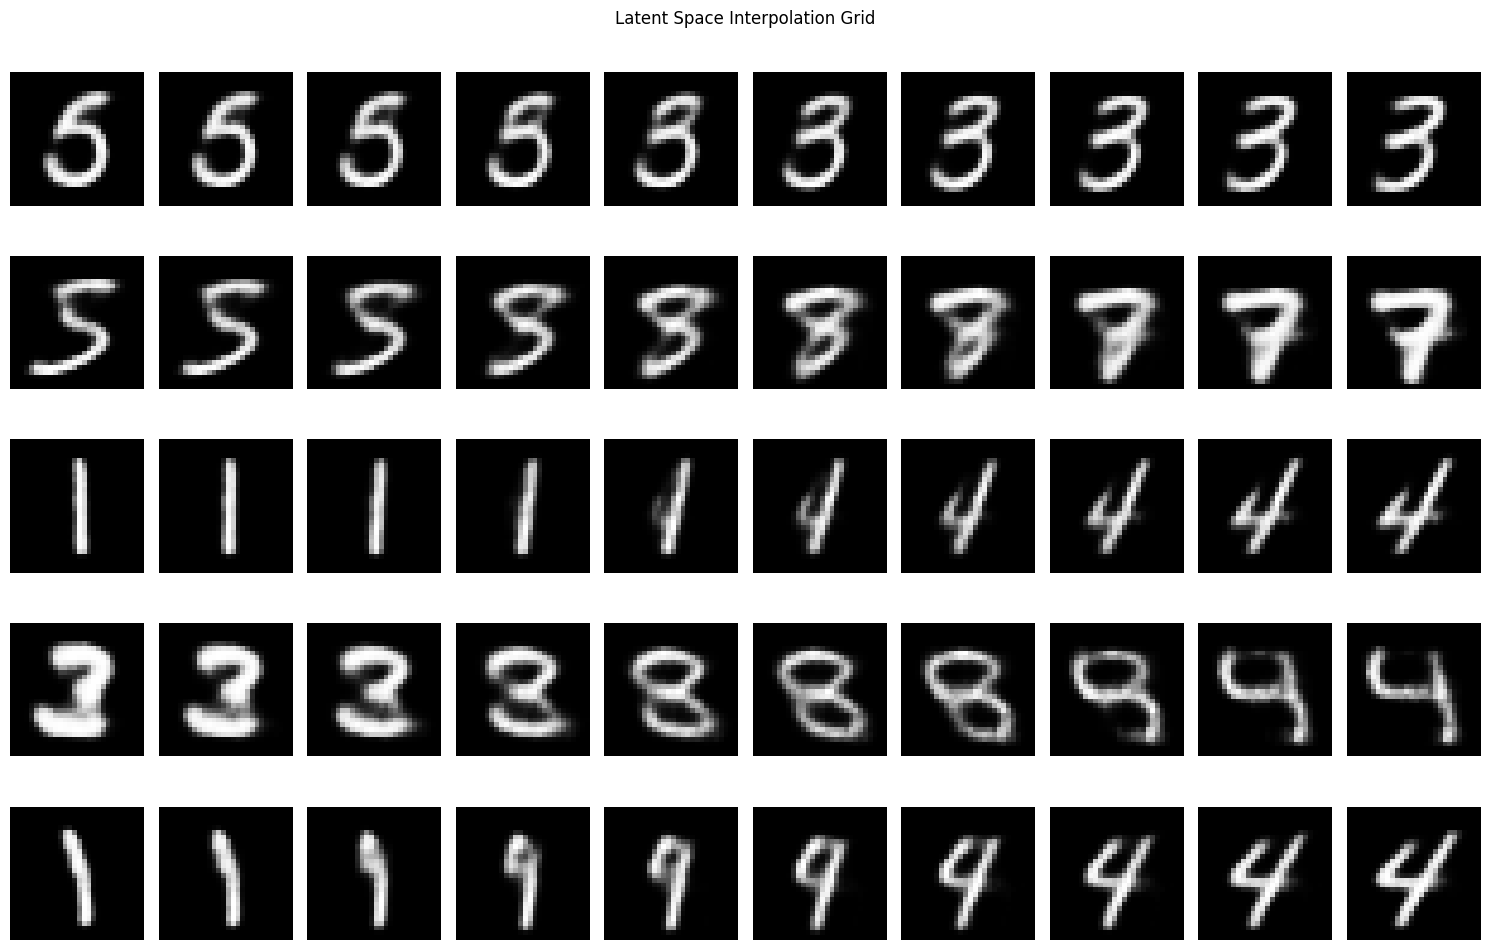

In [30]:
model.eval()

x_batch, _ = next(iter(loader))

num_rows = 5
steps = 10

fig, axes = plt.subplots(num_rows, steps, figsize=(15, 2 * num_rows))

with torch.no_grad():

    for row in range(num_rows):

        x1 = x_batch[row].to(device)
        x2 = x_batch[row + num_rows].to(device)

        mu1, _ = model.encoder(x1.unsqueeze(0))
        mu2, _ = model.encoder(x2.unsqueeze(0))

        for col, alpha in enumerate(np.linspace(0, 1, steps)):

            z = (1 - alpha) * mu1 + alpha * mu2
            img = model.decoder(z)

            img = img.cpu().squeeze(0)[0]

            axes[row, col].imshow(img, cmap="gray")
            axes[row, col].axis("off")

plt.suptitle("Latent Space Interpolation Grid")
plt.tight_layout()
plt.show()

### Latent Distribution Histogram

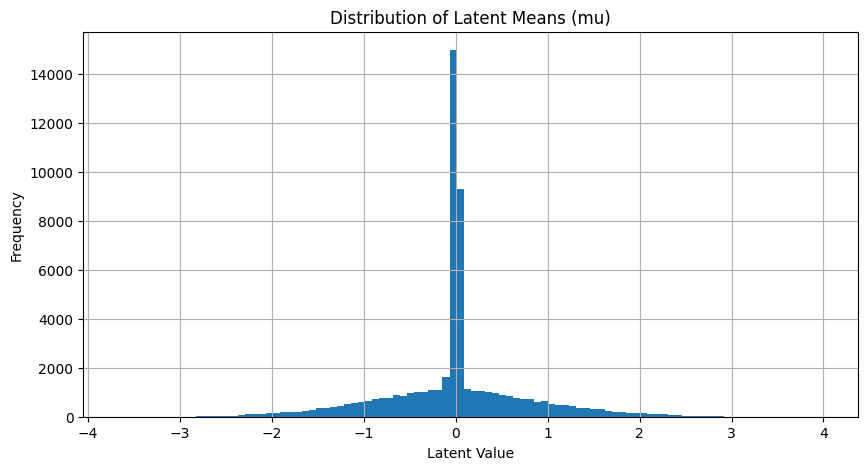

In [23]:
mus = []

model.eval()

with torch.no_grad():

    for batch_idx, (x, _) in enumerate(loader):

        x = x.to(device)

        mu, _ = model.encoder(x)

        mus.append(mu.cpu().numpy())

        if batch_idx > 20:
            break

mus = np.concatenate(mus, axis=0)

plt.figure(figsize=(10, 5))

plt.hist(mus.flatten(), bins=100)

plt.title("Distribution of Latent Means (mu)")
plt.xlabel("Latent Value")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()


### Random Sampling from Latent Space

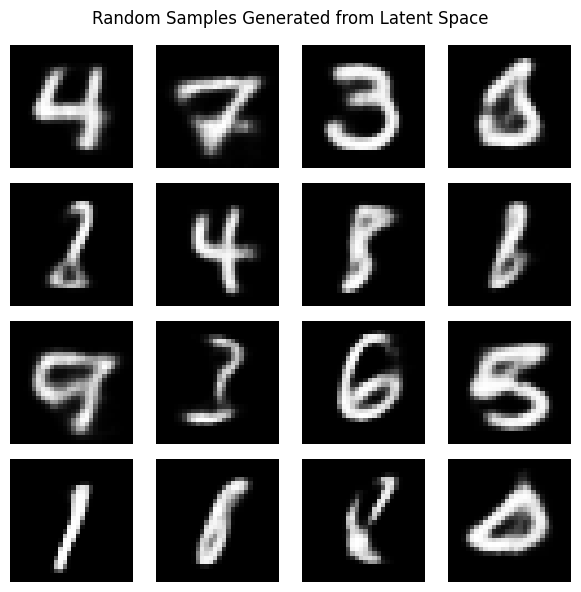

In [24]:
model.eval()

with torch.no_grad():

    z = torch.randn(16, model.latent_dim).to(device)

    generated = model.decoder(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

idx = 0

for i in range(4):
    for j in range(4):

        axes[i, j].imshow(generated[idx][0], cmap="gray")
        axes[i, j].axis("off")

        idx += 1

plt.suptitle("Random Samples Generated from Latent Space")

plt.tight_layout()

plt.show()